# Analyse du churn des clients – Telco

## Objectif de l’analyse
L’analyse permettra notamment de :

    identifier les profils de clients les plus susceptibles de se désabonner

    comprendre combien de temps les clients restent généralement actifs

    analyser l’impact des facteurs financiers et contractuels

    identifier les variables les plus associées au churn

    proposer des actions concrètes pour améliorer la rétention des clients

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

CustomerID : Identifiant unique du client.

Gender : Sexe du client (homme ou femme).

SeniorCitizen : Indique si le client est une personne âgée (1 = oui, 0 = non).

Partner : Indique si le client est en couple (Yes / No).

Dependents : Indique si le client a des personnes à charge (enfants ou autres).

Tenure : Ancienneté du client en nombre de mois depuis son abonnement.

PhoneService : Indique si le client possède un service téléphonique.

MultipleLines : Indique si le client a plusieurs lignes téléphoniques.

InternetService : Type de service internet (DSL, fibre optique ou aucun).

OnlineSecurity : Indique si le client possède un service de sécurité en ligne.

DeviceProtection : Indique si le client a une protection pour ses appareils.

TechSupport : Indique si le client a accès à une assistance technique.

StreamingTV : Indique si le client utilise un service de télévision en streaming.

StreamingMovies : Indique si le client utilise un service de films en streaming.

Contract : Type de contrat (mensuel, 1 an, 2 ans).

PaperlessBilling : Indique si la facturation est électronique (sans papier).

PaymentMethod : Méthode de paiement utilisée par le client.

MonthlyCharges : Montant payé par le client chaque mois.

TotalCharges : Montant total payé par le client depuis le début de son abonnement.

Churn : Indique si le client s’est désabonné (Yes) ou s’il est resté (No).


## Nettoyage des données

Avant l’analyse, certaines opérations de nettoyage sont nécessaires.

- La variable **TotalCharges** est convertie en valeur numérique car certaines
  observations contiennent des valeurs non numériques.

- Les valeurs manquantes apparaissent après la conversion. Ces lignes sont supprimées
  car elles représentent une très petite proportion des données et ne permettent
  pas d'analyser correctement les dépenses totales des clients.

- Les doublons sont vérifiés afin d'éviter de compter plusieurs fois le même client.

In [2]:
df = pd.read_csv("telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [8]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [9]:
df = df.dropna()
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [10]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Analyse du profil des clients qui churn

In [11]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

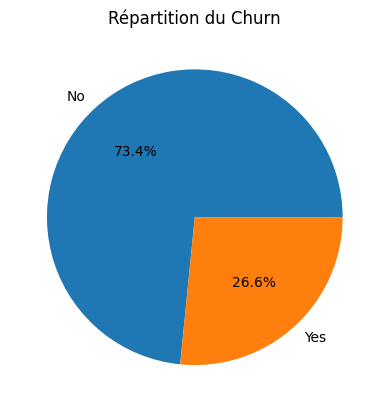

In [12]:
counts = df['Churn'].value_counts()
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%')
plt.title('Répartition du Churn')
plt.show()

### Répartition du churn

Ce graphique montre la proportion de clients qui restent sur la plateforme
et ceux qui quittent le service.

On observe que **73,4 % des clients conservent leur abonnement**, tandis que
**26,6 % se désabonnent**.

Bien que la majorité des clients restent, un taux de churn de près de **27 %**
reste significatif. Il est donc important d’identifier les facteurs qui
expliquent ces départs afin d’améliorer la rétention des clients.

In [13]:
senior_churn = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index')
senior_churn

Churn,No,Yes
SeniorCitizen,,
0,0.763497,0.236503
1,0.583187,0.416813


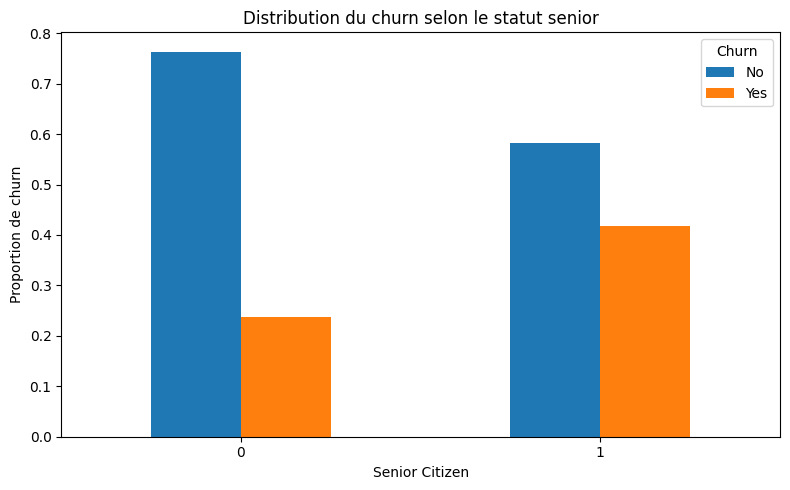

In [14]:
senior_churn.plot(kind='bar', figsize=(8,5))

plt.xlabel('Senior Citizen')
plt.ylabel('Proportion de churn')
plt.title('Distribution du churn selon le statut senior')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [15]:
senior_table = pd.crosstab(df['SeniorCitizen'], df['Churn'])
chi2, p, dof, expected = stats.chi2_contingency(senior_table)
print(f"p-value: {p}")

p-value: 2.4792557203954705e-36


### Impact du statut senior sur le churn

L'analyse montre que les clients seniors présentent un taux
de churn significativement plus élevé que les autres clients.

En effet, environ 42 % des clients seniors quittent le service,
contre seulement 23 % des clients non seniors.

Le test du chi-square confirme que cette relation est
statistiquement significative (p-value < 0.05).

Ces résultats suggèrent que les clients seniors constituent
un segment particulièrement à risque et pourraient nécessiter
des stratégies de fidélisation spécifiques.

In [16]:
gender_churn = pd.crosstab(df['gender'], df['Churn'], normalize='index')
gender_churn

Churn,No,Yes
gender,,
Female,0.730405,0.269595
Male,0.737954,0.262046


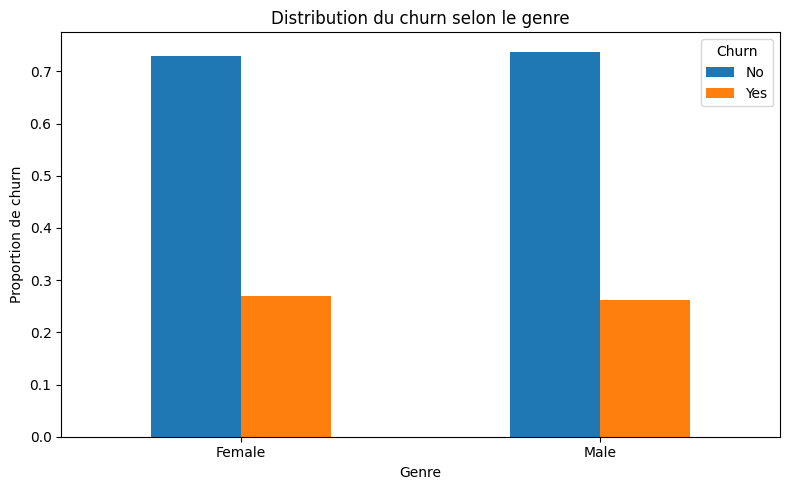

In [17]:
gender_churn.plot(kind='bar', figsize=(8,5))

plt.xlabel('Genre')
plt.ylabel('Proportion de churn')
plt.title('Distribution du churn selon le genre')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Impact du genre sur le churn

L'analyse montre que le taux de churn est très similaire
entre les hommes et les femmes.

Les femmes présentent un taux de churn d'environ 27 %,
tandis que les hommes présentent un taux d'environ 26 %.

Le test du chi-square confirme que cette différence n'est
pas statistiquement significative (p-value = 0.49).

Ces résultats suggèrent que le genre n'est pas un facteur
important dans la décision des clients de quitter le service.

In [18]:
gender_table = pd.crosstab(df['gender'], df['Churn'])
chi2, p, dof, expected = stats.chi2_contingency(gender_table)
print(f"p-value: {p}")

p-value: 0.4904884707065509


In [19]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'])
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [20]:
chi2, p , dof, expected = stats.chi2_contingency(contract_churn)
print(f'p-value: {p}, chi:{chi2}')

p-value: 7.326182186265472e-257, chi:1179.5458287339445


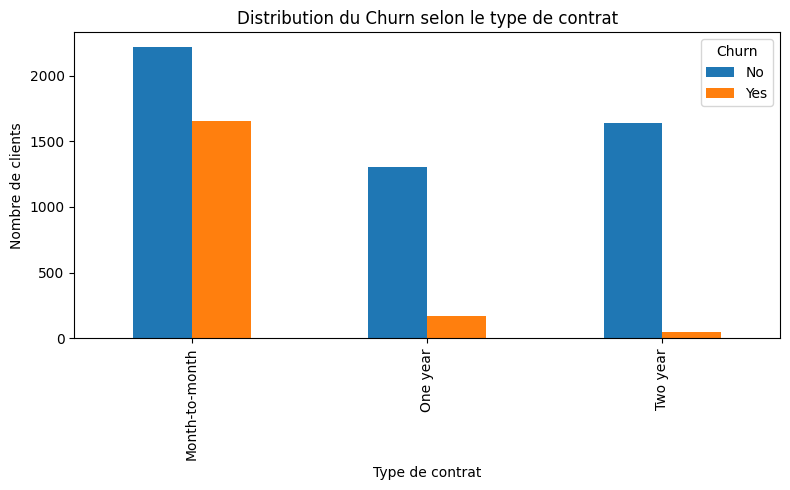

In [21]:
contract_churn.plot(kind='bar', figsize=(8,5))
plt.xlabel('Type de contrat')
plt.ylabel("Nombre de clients")
plt.title("Distribution du Churn selon le type de contrat")
plt.tight_layout()
plt.show()

### Impact du type de contrat sur le churn

Le tableau de contingence montre que les clients ayant un contrat
"Month-to-month" présentent un taux de churn beaucoup plus élevé
que ceux ayant un contrat d'un ou deux ans.

Le test du Chi² donne une p-value extrêmement faible (p < 0.05),
ce qui indique que la relation entre le type de contrat et le churn
est statistiquement significative.

Cela signifie que le type de contrat est un facteur important
dans la décision des clients de quitter le service.

Interprétation business :

Les contrats mensuels offrent plus de flexibilité, ce qui permet
aux clients de quitter facilement l'entreprise. À l'inverse,
les contrats plus longs encouragent la fidélité.

L'entreprise pourrait donc réduire le churn en incitant les clients
à souscrire à des contrats plus longs (réductions, avantages, etc.).

In [22]:
bins = [0, 25, 50, 75, 100, 125]
labels = ['0-25', '25-50', '50-75', '75-100', '100-125']
df['MonthlyCharges_bins'] = pd.cut(df['MonthlyCharges'], bins=bins, labels=labels, right=False)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,MonthlyCharges_bins
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,25-50
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,50-75
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,50-75
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-50
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,50-75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,75-100
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,100-125
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,25-50
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,50-75


In [23]:
monthlyCharges_churn = pd.crosstab(df['MonthlyCharges_bins'], df['Churn'])
monthlyCharges_churn

Churn,No,Yes
MonthlyCharges_bins,,
0-25,1258,127
25-50,669,234
50-75,1193,424
75-100,1392,827
100-125,651,257


In [24]:
monthlyCharges_churn_rate = pd.crosstab(df['MonthlyCharges_bins'], df['Churn'], normalize='index')
monthlyCharges_churn_rate

Churn,No,Yes
MonthlyCharges_bins,,
0-25,0.908303,0.091697
25-50,0.740864,0.259136
50-75,0.737786,0.262214
75-100,0.627310,0.372690
100-125,0.716960,0.283040


In [25]:
chi2, p , dof, expected = stats.chi2_contingency(monthlyCharges_churn)
print(f'p-value: {p}, chi:{chi2}')

p-value: 8.820734867502674e-74, chi:346.75080431108364


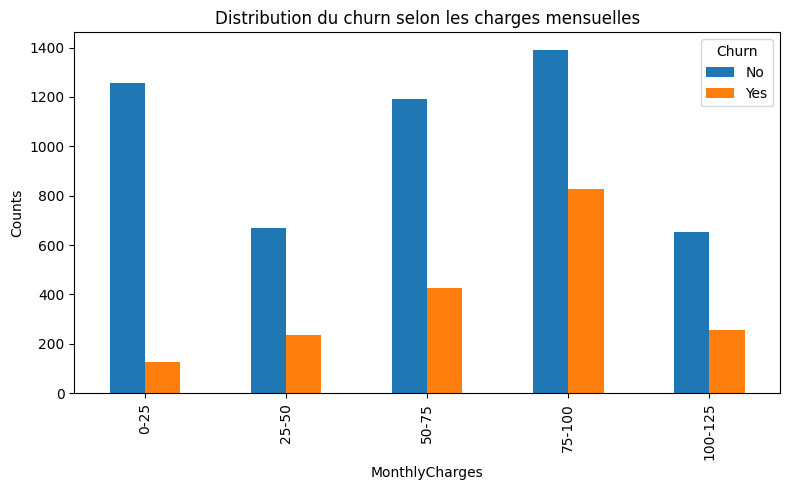

In [26]:
monthlyCharges_churn.plot(kind='bar', figsize=(8,5))
plt.xlabel('MonthlyCharges')
plt.ylabel('Counts')
plt.title('Distribution du churn selon les charges mensuelles')
plt.tight_layout()
plt.show()

### Impact des charges mensuelles sur le churn

L’analyse montre que les clients ayant des charges mensuelles plus élevées
présentent un taux de churn plus important.

Le test du Chi² confirme que la relation entre les charges mensuelles
et le churn est statistiquement significative (p-value < 0.05).

Interprétation business :

Les clients payant des montants élevés peuvent être plus sensibles
au prix et donc plus enclins à quitter le service. Cela peut également
indiquer que certaines offres ou services premium ne répondent pas
totalement aux attentes des clients.

L’entreprise pourrait analyser plus précisément la satisfaction des
clients ayant des charges élevées ou proposer des offres mieux adaptées
afin de réduire le churn.

In [27]:
bins = [
    0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50,
        55, 60, 65, 70, 75]
labels = [
    '0-5', '5-10', '10-15', '15-20', '20-25', 
    '25-30', '30-35', '35-40', '40-45', '45-50',
    '50-55', '55-60', '60-65', '65-70', '70-75'
]

df['tenure_bins'] = pd.cut(df['tenure'], bins=bins, labels=labels)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,MonthlyCharges_bins,tenure_bins
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,25-50,0-5
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,50-75,30-35
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,50-75,0-5
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-50,40-45
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,50-75,0-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,75-100,20-25
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,100-125,70-75
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,25-50,10-15
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,50-75,0-5


In [28]:
tenure_churn = pd.crosstab(df['tenure_bins'], df['Churn'])
tenure_churn 

Churn,No,Yes
tenure_bins,,
0-5,616,744
5-10,375,224
10-15,332,168
15-20,293,115
20-25,308,103
25-30,281,71
30-35,275,76
35-40,229,65
40-45,257,55


In [29]:
tenure_churn_rate = pd.crosstab(df['tenure_bins'], df['Churn'], normalize='index')
tenure_churn_rate

Churn,No,Yes
tenure_bins,,
0-5,0.452941,0.547059
5-10,0.626043,0.373957
10-15,0.664000,0.336000
15-20,0.718137,0.281863
20-25,0.749392,0.250608
25-30,0.798295,0.201705
30-35,0.783476,0.216524
35-40,0.778912,0.221088
40-45,0.823718,0.176282


In [30]:
chi2, p , dof, expected = stats.chi2_contingency(tenure_churn)
print(f'p-value: {p}, chi:{chi2}')

p-value: 2.0338591398354117e-204, chi:999.4693825484828


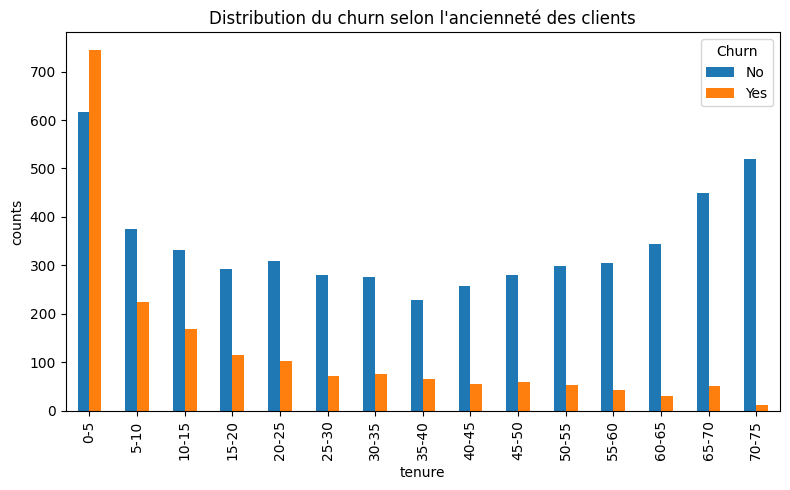

In [31]:
tenure_churn.plot(kind='bar', figsize=(8,5))
plt.xlabel('tenure')
plt.ylabel('counts')
plt.title("Distribution du churn selon l'ancienneté des clients")
plt.tight_layout()
plt.show()

### Impact de l'ancienneté du client sur le churn

L'analyse montre que les clients ayant une faible ancienneté présentent
un taux de churn beaucoup plus élevé que les clients plus anciens.

Les clients ayant moins de 5 mois d'ancienneté quittent le service
beaucoup plus fréquemment que ceux qui sont abonnés depuis plusieurs années.

Le test du Chi² confirme que la relation entre l'ancienneté et le churn
est statistiquement significative (p-value < 0.05).

Interprétation business :

Les premiers mois sont critiques dans la relation entre le client et
l'entreprise. Si l'expérience initiale n'est pas satisfaisante,
les clients peuvent rapidement quitter le service.

L'entreprise devrait donc accorder une attention particulière aux
nouveaux clients afin d'améliorer leur expérience durant les premiers
mois d'abonnement.

In [32]:
internet_service = pd.crosstab(df['InternetService'], df['Churn'])
internet_service

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


In [33]:
internet_service_rate = pd.crosstab(df['InternetService'], df['Churn'], normalize='index')
internet_service_rate

Churn,No,Yes
InternetService,,
DSL,0.810017,0.189983
Fiber optic,0.581072,0.418928
No,0.925658,0.074342


In [34]:
chi2, p , dof, expected = stats.chi2_contingency(internet_service)
print(f'p-value: {p}, chi:{chi2}')

p-value: 5.831198962237274e-159, chi:728.6956143058694


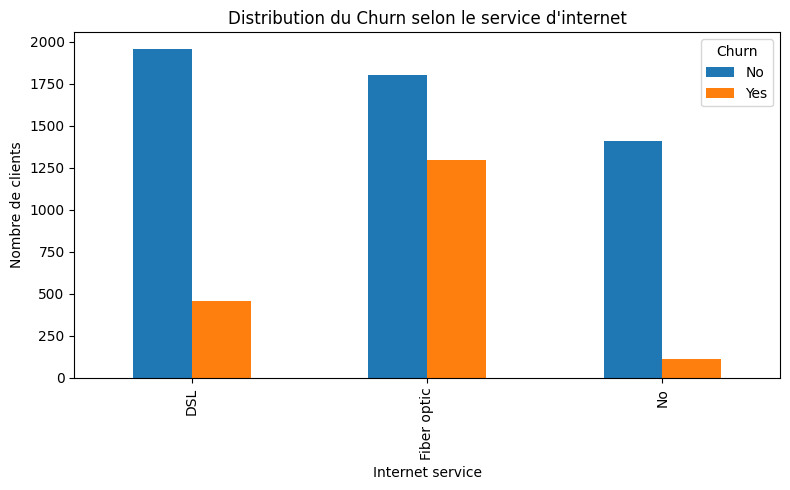

In [35]:
internet_service.plot(kind='bar', figsize=(8,5))
plt.xlabel("Internet service")
plt.ylabel('Nombre de clients')
plt.title("Distribution du Churn selon le service d'internet")
plt.tight_layout()
plt.show()

### Impact du type de service internet sur le churn

L'analyse montre que les clients utilisant la fibre optique présentent
un taux de churn beaucoup plus élevé que ceux utilisant le DSL ou
ceux n'ayant pas de service internet.

Le test du Chi² confirme que la relation entre le type de service
internet et le churn est statistiquement significative (p-value < 0.05).

Interprétation business :

Les clients utilisant la fibre optique peuvent avoir des attentes
plus élevées concernant la qualité du service. Si ces attentes
ne sont pas satisfaites ou si les prix sont élevés, ils peuvent
être plus enclins à quitter le service.

L'entreprise pourrait analyser plus précisément la satisfaction
des clients utilisant la fibre optique afin d'identifier les
raisons spécifiques de leur départ.

## Étudier les facteurs financiers et contractuels

In [37]:
monthlyCharges_intservice = pd.crosstab([df['MonthlyCharges_bins'],df['InternetService']], df['Churn'], normalize='index')
monthlyCharges_intservice

Churn                                      No       Yes
MonthlyCharges_bins InternetService                    
0-25                DSL              0.538462  0.461538
                    No               0.919019  0.080981
25-50               DSL              0.684499  0.315501
                    No               0.977011  0.022989
50-75               DSL              0.842235  0.157765
                    Fiber optic      0.420000  0.580000
75-100              DSL              0.955916  0.044084
                    Fiber optic      0.548098  0.451902
100-125             Fiber optic      0.716960  0.283040

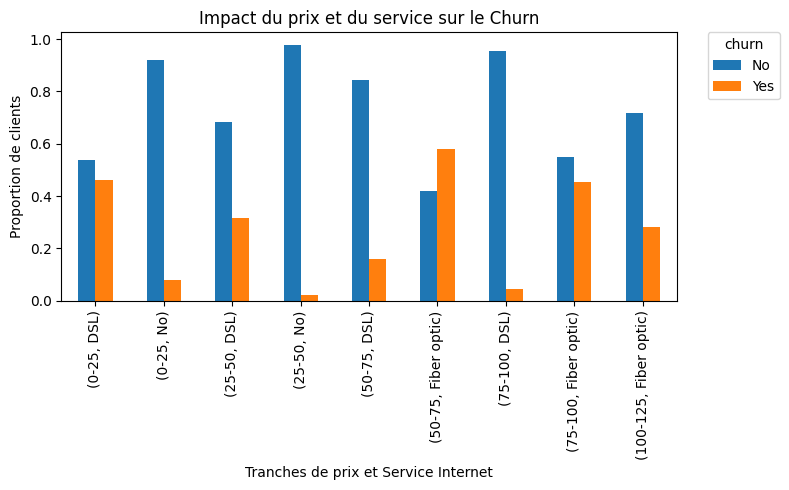

In [38]:
monthlyCharges_intservice.plot(kind='bar', figsize=(8,5))
plt.xlabel('Tranches de prix et Service Internet')
plt.ylabel('Proportion de clients')
plt.title('Impact du prix et du service sur le Churn')
plt.legend(title='churn', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Impact combiné du prix et du service internet sur le churn

L'analyse croisée entre les charges mensuelles et le type de service
internet montre que le churn est particulièrement élevé pour les
clients utilisant la fibre optique avec des charges mensuelles élevées.

Par exemple, les clients utilisant la fibre optique et payant entre
50 et 75 unités présentent un taux de churn supérieur à 50 %.

À l'inverse, les clients sans service internet ou utilisant le DSL
présentent des taux de churn beaucoup plus faibles.

Interprétation business :

Ces résultats suggèrent que les clients fibre optique peuvent être
plus sensibles au prix ou avoir des attentes plus élevées concernant
la qualité du service.

L'entreprise pourrait analyser plus en détail l'expérience des
clients fibre optique afin d'identifier les causes potentielles
de leur départ.

In [39]:
phone_service = pd.crosstab(df['PhoneService'], df['Churn'])
phone_service

Churn,No,Yes
PhoneService,,
No,510,170
Yes,4653,1699


In [40]:
chi2, p , dof, expected = stats.chi2_contingency(phone_service)
print(f'p-value: {p}, chi:{chi2}')

p-value: 0.34992398942431924, chi:0.8737327674431736


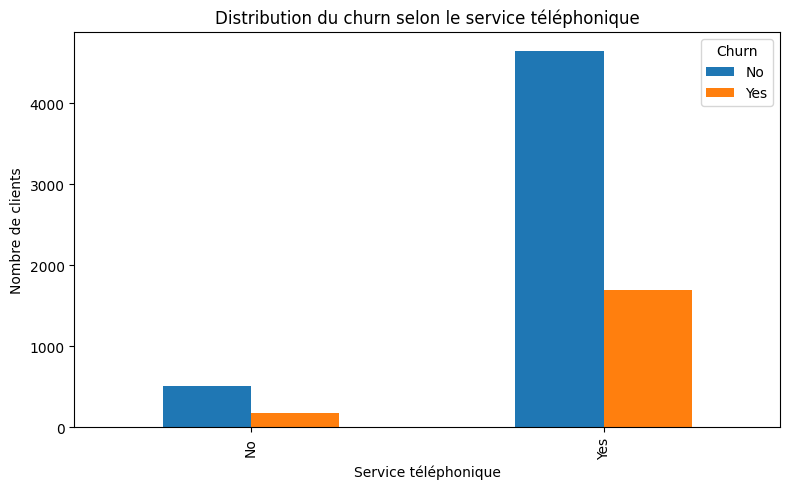

In [41]:
phone_service.plot(kind='bar', figsize=(8,5))
plt.xlabel('Service téléphonique')
plt.ylabel('Nombre de clients')
plt.title('Distribution du churn selon le service téléphonique')
plt.tight_layout()
plt.show()

### Impact du service téléphonique sur le churn

Le tableau de contingence montre la distribution du churn selon
la présence ou non d'un service téléphonique.

Le test du Chi² donne une p-value de 0.35, ce qui est supérieur
au seuil de 0.05. Cela signifie qu'il n'existe pas de relation
statistiquement significative entre le service téléphonique et le churn.

Interprétation :

La présence d'un service téléphonique ne semble pas influencer
la décision des clients de quitter la plateforme.

In [42]:
streaming_movie = pd.crosstab(df['StreamingMovies'], df['Churn'], normalize='index')
streaming_movie

Churn,No,Yes
StreamingMovies,,
No,0.662711,0.337289
No internet service,0.925658,0.074342
Yes,0.700476,0.299524


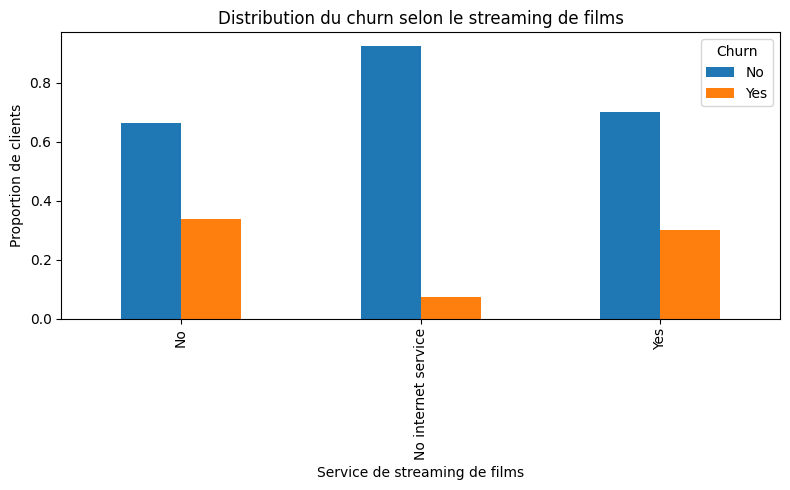

In [43]:
streaming_movie.plot(kind='bar', figsize=(8,5))
plt.xlabel('Service de streaming de films')
plt.ylabel('Proportion de clients')
plt.title('Distribution du churn selon le streaming de films')
plt.tight_layout()
plt.show()

### Impact du service de streaming de films sur le churn

L'analyse montre que les clients ayant accès au service de streaming
de films présentent un taux de churn relativement proche de ceux
qui ne l'utilisent pas.

En revanche, les clients n'ayant pas de service internet présentent
un taux de churn beaucoup plus faible.

Cela suggère que le service de streaming de films n'est pas un facteur
majeur expliquant le churn des clients.

In [44]:
streaming_tv = pd.crosstab(df['StreamingTV'], df['Churn'], normalize='index')
streaming_tv

Churn,No,Yes
StreamingTV,,
No,0.664649,0.335351
No internet service,0.925658,0.074342
Yes,0.698853,0.301147


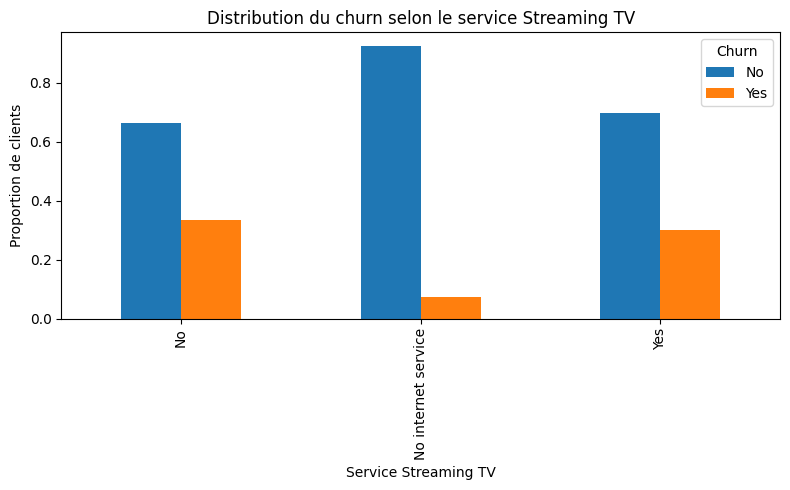

In [45]:
streaming_tv.plot(kind='bar', figsize=(8,5))
plt.xlabel('Service Streaming TV')
plt.ylabel('Proportion de clients')
plt.title('Distribution du churn selon le service Streaming TV')
plt.tight_layout()
plt.show()

### Impact du service StreamingTV sur le churn

L'analyse montre que les clients utilisant le service StreamingTV
présentent un taux de churn relativement proche de ceux qui ne
l'utilisent pas.

Les clients sans service internet présentent en revanche un taux
de churn beaucoup plus faible.

Ces résultats suggèrent que le service StreamingTV n'est pas un
facteur majeur expliquant le churn des clients.

In [46]:
paper = pd.crosstab(df['PaperlessBilling'], df['Churn'])
paper

Churn,No,Yes
PaperlessBilling,,
No,2395,469
Yes,2768,1400


In [47]:
paper_rate = pd.crosstab(df['PaperlessBilling'], df['Churn'], normalize='index')
paper_rate

Churn,No,Yes
PaperlessBilling,,
No,0.836243,0.163757
Yes,0.664107,0.335893


In [48]:
chi2, p , dof, expected = stats.chi2_contingency(paper)
print(f'p-value: {p}, chi:{chi2}')

p-value: 8.236203353962564e-58, chi:256.87490836218717


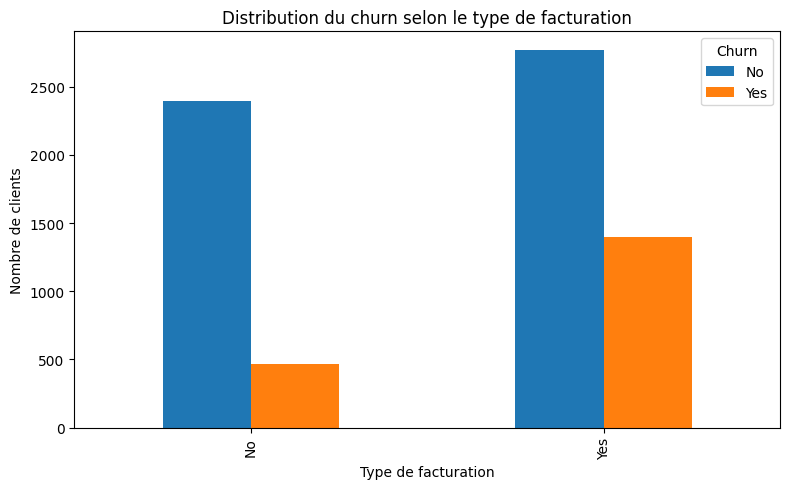

In [49]:
paper.plot(kind='bar', figsize=(8,5))
plt.xlabel('Type de facturation')
plt.ylabel('Nombre de clients')
plt.title('Distribution du churn selon le type de facturation')
plt.tight_layout()
plt.show()

### Impact de la facturation électronique sur le churn

L'analyse montre que les clients utilisant la facturation électronique
(Paperless Billing) présentent un taux de churn plus élevé que ceux
utilisant une facturation papier.

Le test du Chi² confirme que la relation entre la facturation
électronique et le churn est statistiquement significative
(p-value < 0.05).

Interprétation business :

Les clients utilisant la facturation électronique peuvent être plus
engagés dans des services numériques et donc plus enclins à comparer
les offres concurrentes. Cela peut faciliter leur décision de changer
de fournisseur.

L'entreprise pourrait analyser plus en détail les comportements
des clients utilisant la facturation électronique afin d'identifier
les raisons spécifiques de leur départ.

In [50]:
payement_method = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')
payement_method

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832685,0.167315
Credit card (automatic),0.847469,0.152531
Electronic check,0.547146,0.452854
Mailed check,0.807980,0.192020


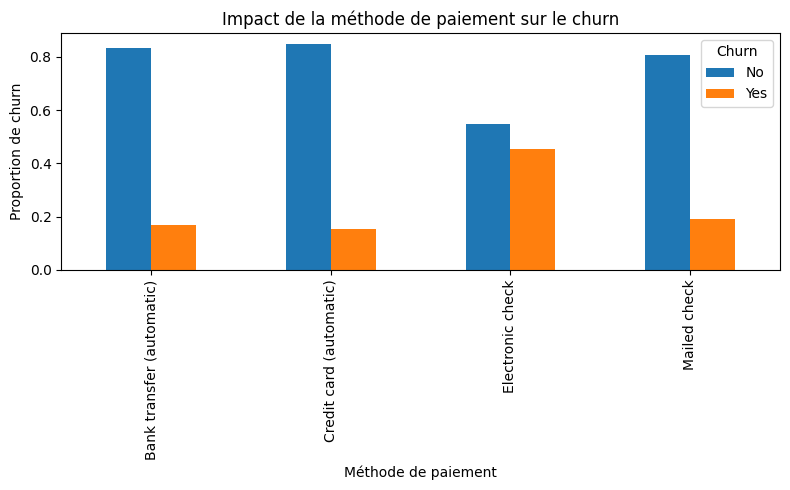

In [51]:
payement_method.plot(kind='bar', figsize=(8,5))
plt.xlabel('Méthode de paiement')
plt.ylabel("Proportion de churn")
plt.title('Impact de la méthode de paiement sur le churn')
plt.tight_layout()
plt.show()

### Impact de la méthode de paiement sur le churn

L'analyse montre que la méthode de paiement est fortement
associée au churn.

Les clients utilisant le paiement par "Electronic check"
présentent le taux de churn le plus élevé (environ 45 %),
ce qui signifie que près d'un client sur deux quitte
le service.

À l'inverse, les méthodes de paiement automatiques comme
la carte de crédit ou le virement bancaire présentent des
taux de churn beaucoup plus faibles.

Interprétation business :

Les paiements automatiques peuvent renforcer la fidélité
des clients en réduisant les frictions liées au paiement,
tandis que les clients utilisant "Electronic check"
semblent être plus susceptibles de quitter la plateforme.

In [52]:
paper_payement = pd.crosstab([df['PaperlessBilling'], df['PaymentMethod']], df['Churn'], normalize='index')
paper_payement

Churn                                             No       Yes
PaperlessBilling PaymentMethod                                
No               Bank transfer (automatic)  0.889740  0.110260
                 Credit card (automatic)    0.899844  0.100156
                 Electronic check           0.672552  0.327448
                 Mailed check               0.864067  0.135933
Yes              Bank transfer (automatic)  0.790776  0.209224
                 Credit card (automatic)    0.809524  0.190476
                 Electronic check           0.502296  0.497704
                 Mailed check               0.726718  0.273282

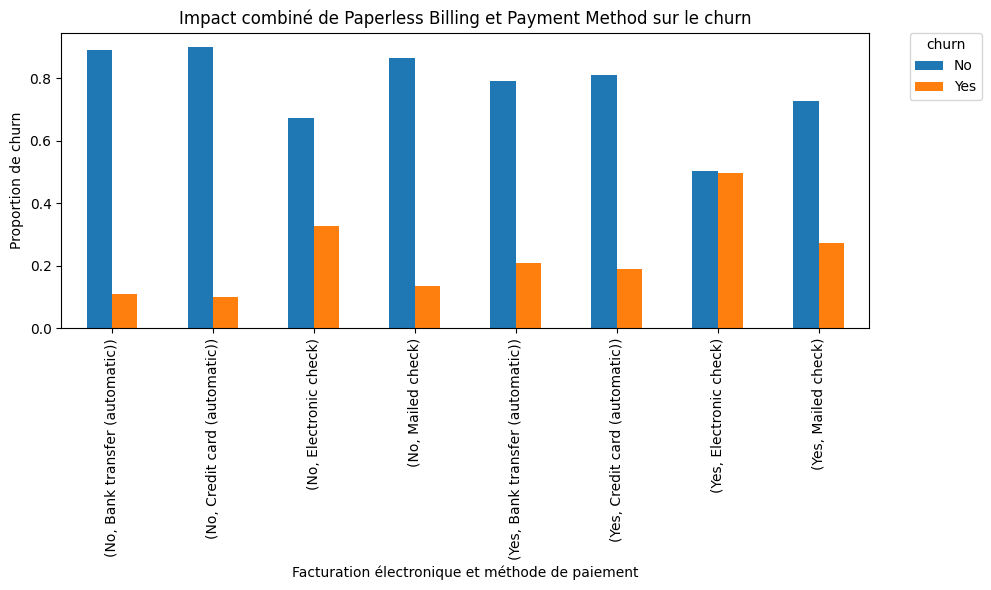

In [53]:
paper_payement.plot(kind='bar', figsize=(10,6))

plt.xlabel('Facturation électronique et méthode de paiement')
plt.ylabel('Proportion de churn')
plt.title('Impact combiné de Paperless Billing et Payment Method sur le churn')
plt.legend(title='churn', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Impact combiné de la facturation électronique et de la méthode de paiement

L'analyse montre que le churn varie selon la combinaison
de la facturation électronique (PaperlessBilling) et de
la méthode de paiement.

Les clients utilisant le paiement par "Electronic check"
présentent les taux de churn les plus élevés, en particulier
lorsqu'ils utilisent également la facturation électronique,
avec un taux proche de 50 %.

À l'inverse, les méthodes de paiement automatiques comme
le virement bancaire ou la carte de crédit présentent des
taux de churn beaucoup plus faibles.

Ces résultats suggèrent que la combinaison de la facturation
électronique et de certains modes de paiement peut être
associée à un risque plus élevé de départ des clients.

In [54]:
streaming = pd.crosstab([df['StreamingMovies'], df['StreamingTV']], df['Churn'], normalize='index')
streaming

Churn                                          No       Yes
StreamingMovies     StreamingTV                            
No                  No                   0.655429  0.344571
                    Yes                  0.681937  0.318063
No internet service No internet service  0.925658  0.074342
Yes                 No                   0.688131  0.311869
                    Yes                  0.705518  0.294482

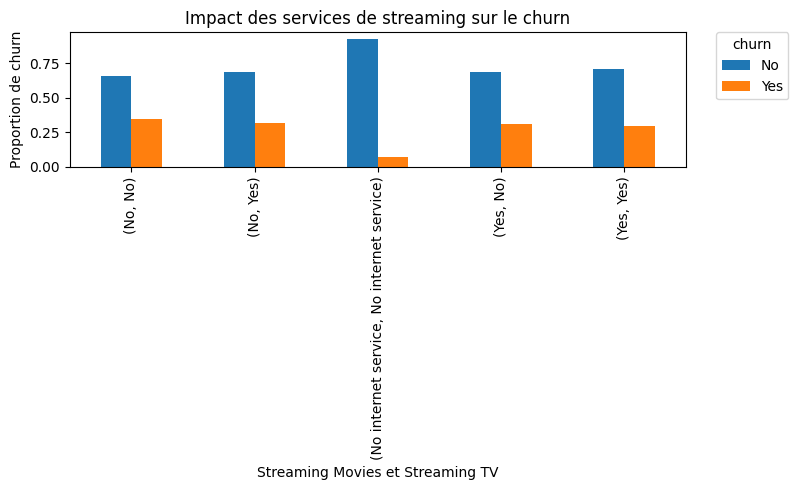

In [55]:
streaming.plot(kind='bar', figsize=(8,5))
plt.xlabel('Streaming Movies et Streaming TV')
plt.ylabel('Proportion de churn')
plt.title('Impact des services de streaming sur le churn')
plt.legend(title='churn', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Impact combiné des services de streaming

L'analyse montre que les services de streaming (StreamingMovies
et StreamingTV) n'ont pas un impact majeur sur le churn.

Les taux de churn restent relativement similaires entre les
différentes combinaisons de services de streaming, avec des
valeurs comprises entre environ 29 % et 34 %.

En revanche, les clients n'ayant pas de service internet
présentent un taux de churn beaucoup plus faible.

Ces résultats suggèrent que les services de streaming ne
constituent pas un facteur déterminant dans la décision
des clients de quitter la plateforme.

In [56]:
service = pd.crosstab([df['PhoneService'], df['InternetService']], df['Churn'], normalize='index')
service

Churn                               No       Yes
PhoneService InternetService                    
No           DSL              0.750000  0.250000
Yes          DSL              0.833525  0.166475
             Fiber optic      0.581072  0.418928
             No               0.925658  0.074342

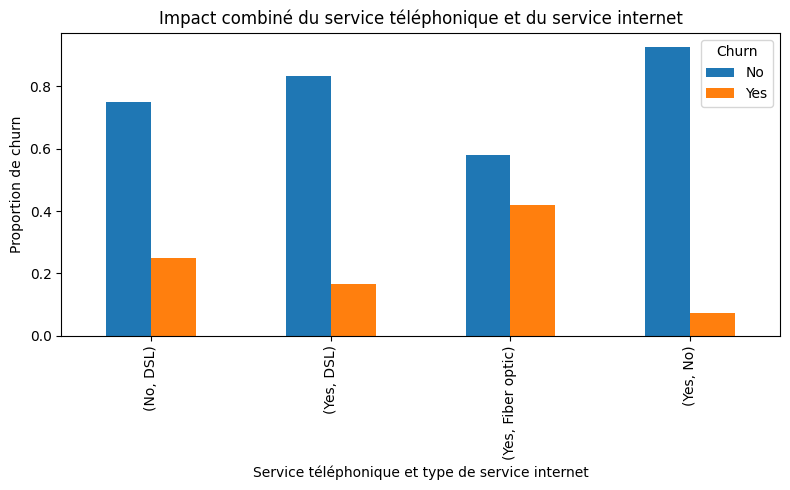

In [57]:
service.plot(kind='bar', figsize=(8,5))
plt.xlabel('Service téléphonique et type de service internet')
plt.ylabel('Proportion de churn')
plt.title('Impact combiné du service téléphonique et du service internet')
plt.tight_layout()
plt.show()

### Impact combiné du service téléphonique et du service internet

L'analyse montre que le taux de churn varie principalement selon
le type de service internet utilisé.

Les clients utilisant la fibre optique présentent un taux de churn
beaucoup plus élevé que ceux utilisant le DSL ou n'ayant pas de
service internet.

La présence d'un service téléphonique ne semble pas avoir un
impact majeur sur le churn.

Ces résultats suggèrent que le type de service internet est
un facteur beaucoup plus déterminant dans la décision des
clients de quitter la plateforme.

In [58]:
contract_monthlycharge = pd.crosstab([df['MonthlyCharges_bins'], df['Contract']], df['Churn'], normalize='index')
contract_monthlycharge

Churn                                     No       Yes
MonthlyCharges_bins Contract                          
0-25                Month-to-month  0.786916  0.213084
                    One year        0.973761  0.026239
                    Two year        0.992110  0.007890
25-50               Month-to-month  0.615652  0.384348
                    One year        0.921875  0.078125
                    Two year        0.985000  0.015000
50-75               Month-to-month  0.610494  0.389506
                    One year        0.910864  0.089136
                    Two year        0.977528  0.022472
75-100              Month-to-month  0.467541  0.532459
                    One year        0.879452  0.120548
                    Two year        0.970443  0.029557
100-125             Month-to-month  0.500000  0.500000
                    One year        0.743682  0.256318
                    Two year        0.924590  0.075410

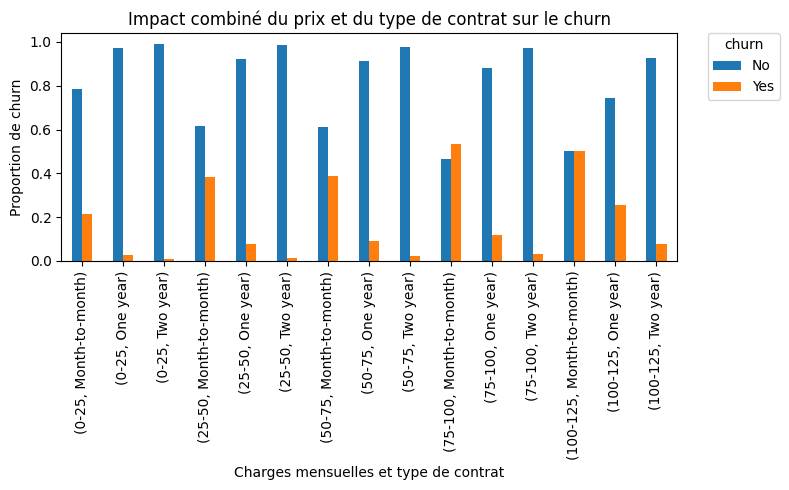

In [59]:
contract_monthlycharge.plot(kind='bar', figsize=(8,5))
plt.xlabel('Charges mensuelles et type de contrat')
plt.ylabel('Proportion de churn')
plt.title('Impact combiné du prix et du type de contrat sur le churn')
plt.legend(title='churn', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Impact combiné des charges mensuelles et du type de contrat

L'analyse montre que le churn est particulièrement élevé chez les
clients ayant un contrat mensuel et des charges mensuelles élevées.

Par exemple, les clients payant entre 75 et 100 unités avec un contrat
mensuel présentent un taux de churn supérieur à 50 %.

À l'inverse, les clients ayant un contrat d'un ou deux ans présentent
des taux de churn beaucoup plus faibles, même lorsque les charges
mensuelles sont élevées.

Interprétation business :

Les contrats mensuels offrent une plus grande flexibilité aux clients,
ce qui facilite leur départ lorsque les prix deviennent élevés ou que
leurs attentes ne sont pas satisfaites.

Encourager les clients à souscrire à des contrats plus longs pourrait
être une stratégie efficace pour réduire le churn.

In [60]:
charges = pd.crosstab([df['MonthlyCharges_bins'], df['PaymentMethod']], df['Churn'], normalize='index')
charges

Churn                                                No       Yes
MonthlyCharges_bins PaymentMethod                                
0-25                Bank transfer (automatic)  0.936842  0.063158
                    Credit card (automatic)    0.974820  0.025180
                    Electronic check           0.784000  0.216000
                    Mailed check               0.892396  0.107604
25-50               Bank transfer (automatic)  0.839080  0.160920
                    Credit card (automatic)    0.846154  0.153846
                    Electronic check           0.566667  0.433333
                    Mailed check               0.779783  0.220217
50-75               Bank transfer (automatic)  0.856734  0.143266
                    Credit card (automatic)    0.838527  0.161473
                    Electronic check           0.588889  0.411111
                    Mailed check               0.746667  0.253333
75-100              Bank transfer (automatic)  0.771488  0.228512
                    Credit card (automatic)    0.797071  0.202929
                    Electronic check           0.474383  0.525617
                    Mailed check               0.680952  0.319048
100-125             Bank transfer (automatic)  0.793774  0.206226
                    Credit card (automatic)    0.813043  0.186957
                    Electronic check           0.598404  0.401596
                    Mailed check               0.777778  0.222222

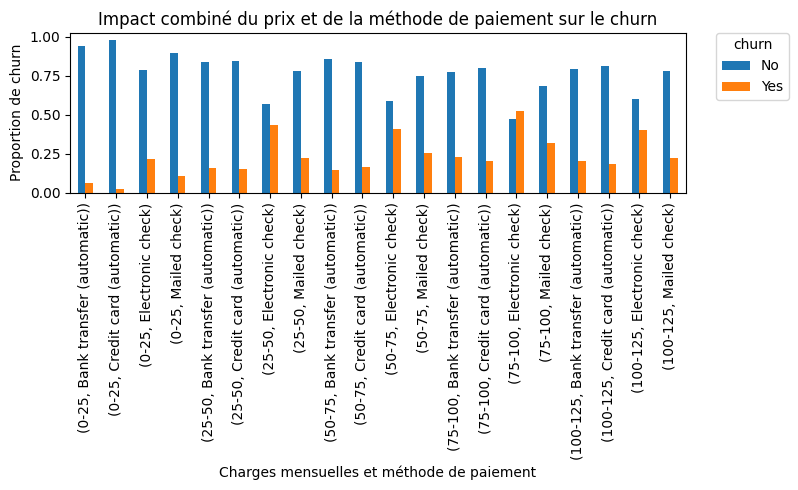

In [61]:
charges.plot(kind='bar', figsize=(8,5))
plt.xlabel('Charges mensuelles et méthode de paiement')
plt.ylabel('Proportion de churn')
plt.title('Impact combiné du prix et de la méthode de paiement sur le churn')
plt.legend(title='churn', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Impact combiné des charges mensuelles et de la méthode de paiement

L'analyse montre que les clients utilisant le paiement par
"Electronic check" présentent les taux de churn les plus élevés
dans presque toutes les tranches de charges mensuelles.

Cette tendance est particulièrement visible pour les clients
ayant des charges mensuelles élevées.

À l'inverse, les clients utilisant des méthodes de paiement
automatiques comme la carte de crédit ou le virement bancaire
présentent des taux de churn plus faibles.

Interprétation business :

Les méthodes de paiement automatiques peuvent favoriser une
relation plus stable entre le client et l'entreprise. À l'inverse,
les clients utilisant le paiement par "Electronic check" peuvent
être moins engagés et plus enclins à quitter le service.

2. ## Quels segments de clientèle sont les plus susceptibles de se désabonner ?
L’analyse des différentes variables permet d’identifier plusieurs segments de clients qui présentent un risque plus élevé de churn.

## Clients avec contrat mensuel
Les clients ayant un contrat "Month-to-month" présentent les taux de churn les plus élevés.
Contrairement aux contrats d’un ou deux ans, ce type de contrat offre plus de flexibilité et permet aux clients de quitter le service plus facilement.

## Clients avec faible ancienneté
Les clients ayant une faible ancienneté (tenure) sont plus susceptibles de quitter la plateforme.
Le churn est particulièrement élevé durant les premiers mois d’abonnement, ce qui indique que les premières expériences avec le service sont déterminantes.

## Clients seniors
Les SeniorCitizen présentent un taux de churn plus élevé que les autres clients.
Environ 42 % des clients seniors quittent le service, contre environ 23 % des clients non seniors.

## Clients avec charges mensuelles élevées
Les clients ayant des MonthlyCharges élevées présentent un taux de churn plus important.
Cela peut indiquer que certains clients jugent le service trop coûteux par rapport à la valeur perçue.

## Clients utilisant Internet Fiber Optic
Les clients utilisant la fibre optique montrent un taux de churn plus élevé que ceux utilisant le DSL ou n’ayant pas de service internet.

## 3. Combien de temps les clients restent-ils généralement actifs ?
La variable tenure permet d'analyser la durée pendant laquelle les clients restent abonnés au service.

L’analyse montre que les clients qui quittent la plateforme ont généralement une ancienneté faible. Le taux de churn est particulièrement élevé chez les clients ayant moins de 10 mois d’ancienneté.

À mesure que l’ancienneté augmente, la probabilité de churn diminue progressivement. Les clients ayant plus de 50 ou 60 mois d’ancienneté présentent un taux de churn beaucoup plus faible.

Cela suggère que les premiers mois de la relation client sont les plus critiques. Les clients qui restent plus longtemps deviennent généralement plus fidèles et sont moins susceptibles de quitter la plateforme.

## 5. Quelles actions peuvent améliorer la fidélisation client ?
À partir des analyses réalisées, plusieurs actions peuvent être mises en place pour réduire le churn et améliorer la fidélisation des clients.

## Encourager les contrats à long terme
Les clients ayant des contrats mensuels (Month-to-month) présentent les taux de churn les plus élevés.
L'entreprise pourrait encourager les clients à choisir des contrats d'un ou deux ans, par exemple en proposant des réductions ou des avantages exclusifs.

## Améliorer l'expérience des nouveaux clients
L’analyse de l’ancienneté (tenure) montre que le churn est plus élevé chez les clients ayant une faible ancienneté.
L'entreprise pourrait améliorer l'expérience des nouveaux clients en proposant :

    -un meilleur accompagnement lors de l'inscription

    -des offres promotionnelles durant les premiers mois

    -un support client renforcé au début de l’abonnement.

## Encourager les paiements automatiques
Les clients utilisant Electronic Check présentent un taux de churn plus élevé que ceux utilisant des paiements automatiques.
L’entreprise pourrait encourager les paiements automatiques (carte bancaire ou virement) en proposant des réductions ou avantages.

## Réévaluer les offres pour les clients avec charges élevées
Les clients ayant des charges mensuelles élevées montrent un taux de churn plus important.
L’entreprise pourrait proposer des offres plus compétitives ou des packages de services afin d'améliorer la perception de la valeur du service.

##Améliorer la satisfaction des clients Fiber Optic
Les clients utilisant la fibre optique présentent un taux de churn plus élevé.
L’entreprise devrait analyser les raisons possibles, telles que :

    -la qualité du service

    -le rapport qualité-prix

    -la satisfaction globale des utilisateurs.

## Conclusion finale
Cette analyse avait pour objectif de comprendre les facteurs associés au churn des clients dans une entreprise de télécommunications. L’étude des différentes variables a permis d’identifier plusieurs tendances importantes.

Les résultats montrent que le churn est particulièrement élevé chez les clients ayant un contrat mensuel, une faible ancienneté, ainsi que chez les clients ayant des charges mensuelles élevées. De plus, certains services comme Fiber Optic et certaines méthodes de paiement comme Electronic Check sont également associés à des taux de churn plus élevés.

L’analyse a également révélé que certains segments de clientèle, notamment les clients seniors, présentent une probabilité plus élevée de quitter la plateforme. En revanche, des variables comme le genre ou certains services de streaming semblent avoir peu d’influence sur le churn.

Ces résultats permettent d’identifier les segments de clients les plus à risque et d’orienter les stratégies de fidélisation. Des actions telles que l’encouragement des contrats à long terme, l’amélioration de l’expérience des nouveaux clients ou la promotion des paiements automatiques pourraient contribuer à réduire le churn et à améliorer la rétention des clients.

